In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/josephsudheer0506/dsb-eda/swift_currency_tracker_all_reports.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/josephsudheer0506/dsb-eda/swift_currency_tracker_all_reports.csv")

In [4]:
print("Shape:", df.shape)

df.head()

Shape: (330, 10)


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2
2,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,GBP,6.73,%,NaN,Rank 3
3,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CAD,3.44,%,NaN,Rank 4
4,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,JPY,3.42,%,NaN,Rank 5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   report_month         330 non-null    object 
 1   data_month           330 non-null    object 
 2   source_report_name   330 non-null    object 
 3   metric               330 non-null    object 
 4   category             330 non-null    object 
 5   currency_or_economy  330 non-null    object 
 6   value                288 non-null    float64
 7   unit                 288 non-null    object 
 8   rmb_global_rank      50 non-null     float64
 9   notes                306 non-null    object 
dtypes: float64(2), object(8)
memory usage: 25.9+ KB


In [6]:
df.describe()

,value,rmb_global_rank
count,288.000000,50.000000
mean,7.013750,5.340000
std,15.885797,0.798212
min,-2.680000,4.000000
25%,0.485000,5.000000
50%,1.060000,6.000000
75%,5.042500,6.000000
max,81.960000,6.000000


In [7]:
df.isnull().sum()

report_month             0
data_month               0
source_report_name       0
metric                   0
category                 0
currency_or_economy      0
value                   42
unit                    42
rmb_global_rank        280
notes                   24
dtype: int64

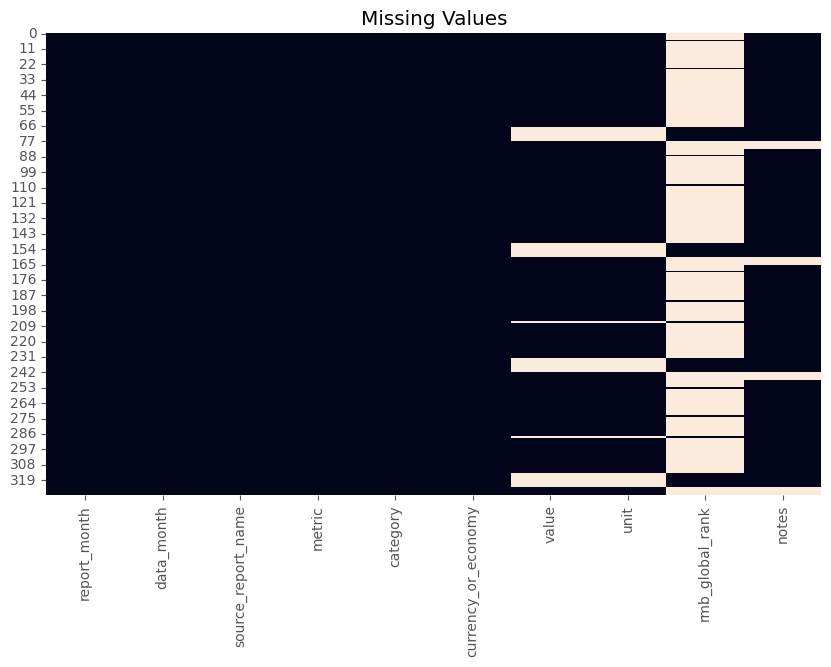

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [9]:
print(df.duplicated().sum())

0


In [10]:
df.describe(include="all")

,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
count,330,330,330,330,330,330,288.000000,288,50.000000,306
unique,4,4,2,8,5,48,NaN,1,NaN,28
top,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,CNY,NaN,%,NaN,Clearing centre
freq,83,83,166,80,200,20,NaN,288,NaN,48
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.013750,NaN,5.340000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,15.885797,NaN,0.798212,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-2.680000,NaN,4.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.485000,NaN,5.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.060000,NaN,6.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.042500,NaN,6.000000,NaN


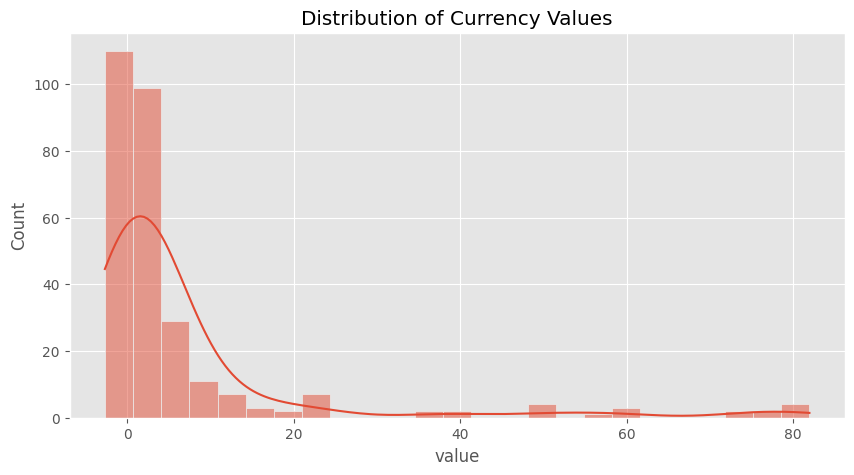

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df["value"], bins=25, kde=True)

plt.title("Distribution of Currency Values")

plt.show()

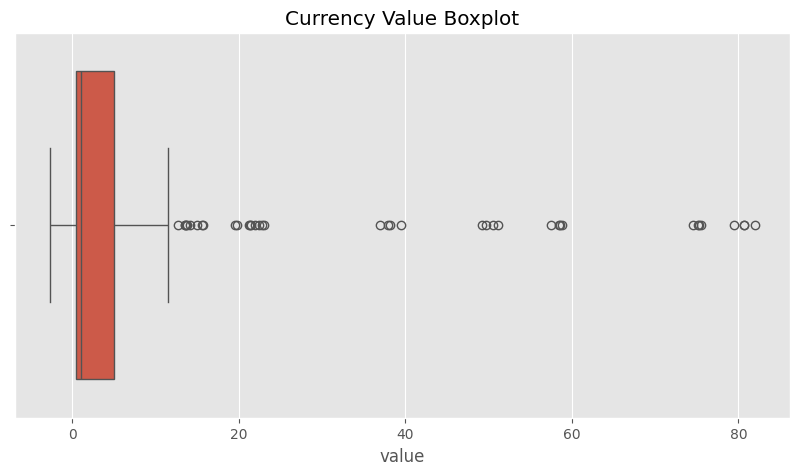

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["value"])

plt.title("Currency Value Boxplot")

plt.show()

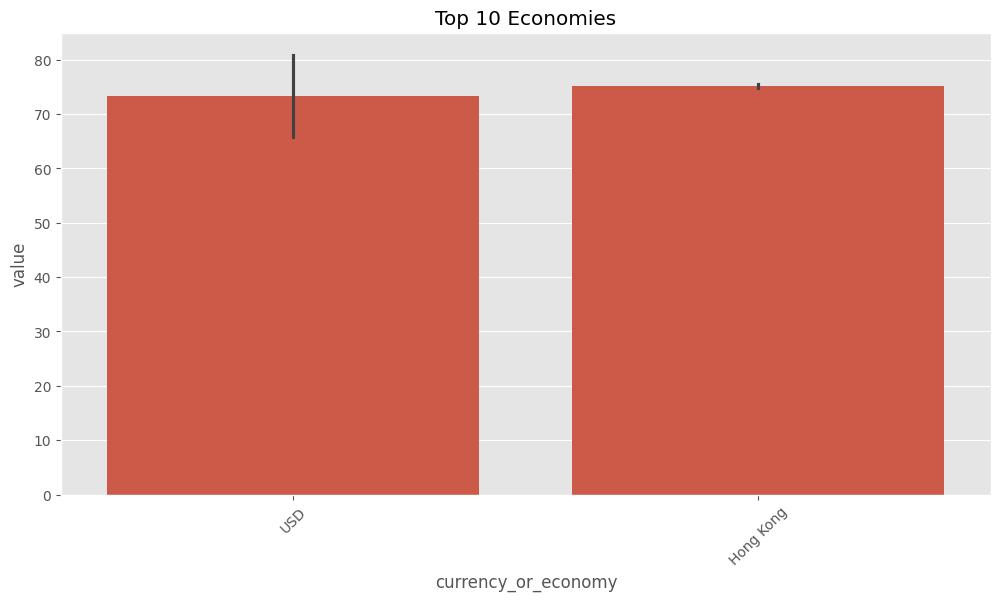

,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
304,March 2026,February 2026,Global Currency Tracker,Trade Finance Share,Currency Ranking,USD,81.96,%,NaN,Rank 1
222,April 2026,March 2026,Global Currency Tracker,Trade Finance Share,Currency Ranking,USD,80.73,%,NaN,Rank 1
140,February 2026,January 2026,RMB Tracker,Trade Finance Share,Currency Ranking,USD,80.70,%,NaN,Rank 1
57,January 2026,December 2025,RMB Tracker,Trade Finance Share,Currency Ranking,USD,79.53,%,NaN,Rank 1
289,March 2026,February 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Hong Kong,75.57,%,NaN,Clearing centre
207,April 2026,March 2026,Global Currency Tracker,Offshore RMB by Economy,Offshore Economies,Hong Kong,75.23,%,NaN,Clearing centre
125,February 2026,January 2026,RMB Tracker,Offshore RMB by Economy,Offshore Economies,Hong Kong,75.11,%,NaN,Clearing centre
42,January 2026,December 2025,RMB Tracker,Offshore RMB by Economy,Offshore Economies,Hong Kong,74.55,%,NaN,Clearing centre
103,February 2026,January 2026,RMB Tracker,International Payment Share (ex-Eurozone),Currency Ranking,USD,58.83,%,NaN,Rank 1
20,January 2026,December 2025,RMB Tracker,International Payment Share (ex-Eurozone),Currency Ranking,USD,58.62,%,NaN,Rank 1


In [13]:
top10 = df.sort_values("value", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="currency_or_economy",
    y="value"
)

plt.xticks(rotation=45)

plt.title("Top 10 Economies")

plt.show()

top10

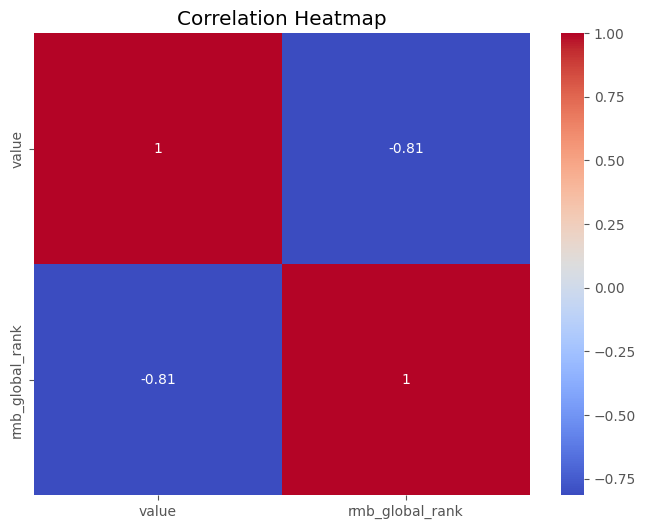

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
Q1 = df["value"].quantile(0.25)

Q3 = df["value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["value"] < lower) |
    (df["value"] > upper)
]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 38


,report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes
0,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,USD,50.49,%,NaN,Rank 1
1,January 2026,December 2025,RMB Tracker,Global Payment Share,Currency Ranking,EUR,21.90,%,NaN,Rank 2
20,January 2026,December 2025,RMB Tracker,International Payment Share (ex-Eurozone),Currency Ranking,USD,58.62,%,NaN,Rank 1
21,January 2026,December 2025,RMB Tracker,International Payment Share (ex-Eurozone),Currency Ranking,EUR,13.68,%,NaN,Rank 2
40,January 2026,December 2025,RMB Tracker,RMB MoM Payment Growth,RMB Activity,CNY,12.65,%,NaN,vs November 2025


/tmp/ipykernel_16/59933388.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["report_month"] = pd.to_datetime(df["report_month"])


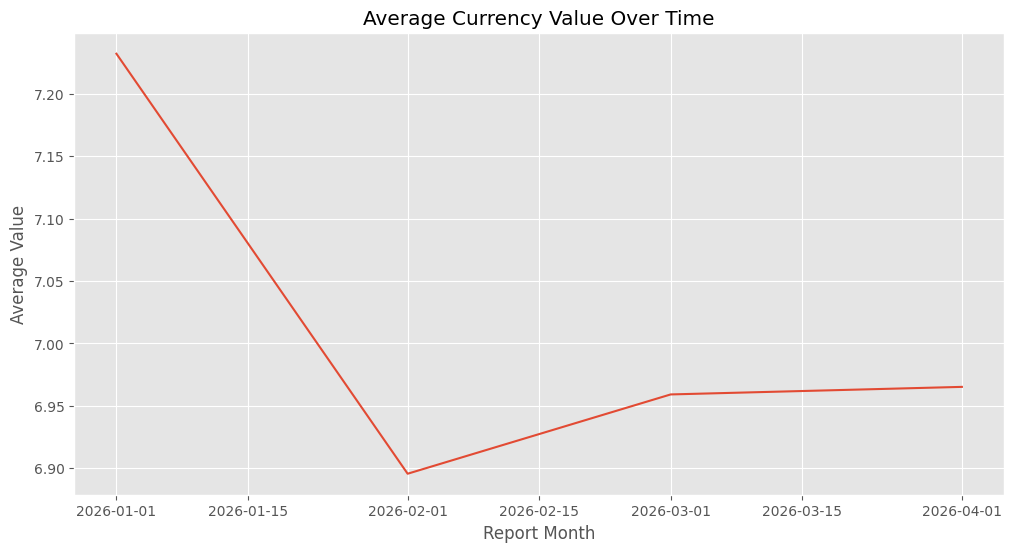

In [16]:
df["report_month"] = pd.to_datetime(df["report_month"])

trend = df.groupby("report_month")["value"].mean()

plt.figure(figsize=(12,6))

plt.plot(trend.index, trend.values)

plt.title("Average Currency Value Over Time")

plt.xlabel("Report Month")

plt.ylabel("Average Value")

plt.show()

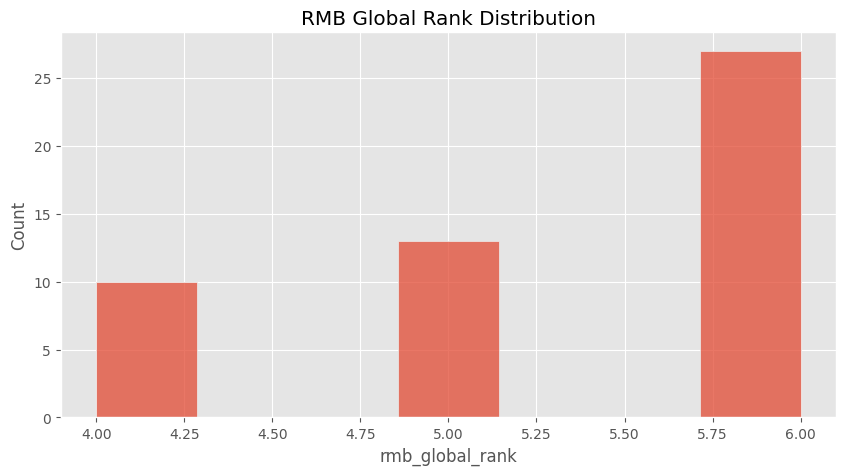

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["rmb_global_rank"].dropna())

plt.title("RMB Global Rank Distribution")

plt.show()

## Key Findings

- The dataset contains ___ rows and ___ columns.
- No duplicate records were found.
- Missing values exist in some variables and were analysed.
- A strong negative correlation exists between currency value and RMB global rank.
- Outlier detection identified unusual observations that may represent exceptional market conditions.

## Research Questions

1. Why does USD remain the dominant global payment currency?
2. Can RMB continue to increase its global payment share?
3. How do geopolitical events affect international currency usage?
4. What role does Hong Kong play in offshore RMB transactions?
5. Can alternative payment systems reduce dependence on USD?